# 07 — MTP / Flash Memory (Calibration NVM)

Phased arrays need per-element calibration data that **survives power-off**:
- Phase offsets (MTPS trim)
- Gain offsets (LNA bias)
- Element kill-bits (radiation upsets)
- Beam-table presets

These live in **on-chip non-volatile memory (MTP)** — Multi-Time Programmable anti-fuse or floating-gate cells.

| Feature | MTP | Flash |
|---------|-----|-------|
| Prog cycles | 10–100 | 10⁴–10⁵ |
| Standard CMOS? | Yes | Needs extra masks |
| Radiation risk | Low | FG charge loss |

**Read principle**: FET V_T shifts when programmed (hot-electron injection). Sense amp detects ΔI.

In [1]:
import sys, os, numpy as np, matplotlib.pyplot as plt
import matplotlib; matplotlib.use('Agg')
os.environ.setdefault('PDK_ROOT', os.path.expanduser('~/pdks'))
try:
    NB_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    NB_DIR = os.getcwd()
_gdir = os.path.abspath(os.path.join(NB_DIR, '..', '..', 'src', 'gelochip'))
if _gdir not in sys.path: sys.path.insert(0, _gdir)
import gdsfactory as gf; from gdsfactory.component import Component
from glayout.pdk.gf180_mapped.gf180_mapped import gf180_mapped_pdk as pdk
from glayout.primitives.fet import nmos, pmos
pdk.activate(); print('gf180 PDK activated')


2026-05-11 22:32:39.097 | INFO     | gdsfactory.pdk:activate:337 - 'gf180' PDK is now active


gf180 PDK activated


In [2]:
import PySpice.Spice.NgSpice.RawFile as _rf
if not getattr(_rf,'_patched',False):
    _o=_rf.RawFile._read_header
    def _p(self,s): pos=s.find(b'Circuit: '); return _o(self,s[pos:] if pos>=0 else s)
    _rf.RawFile._read_header=_p; _rf._patched=True
print('PySpice patch applied')


PySpice patch applied


## 1. Bit-Cell Sizing — Sense Margin

In [3]:
VDD           = 1.8
KP_N          = 200e-6        # A/V²
WL_CELL       = 2e-6/180e-9   # W/L of storage FET
VT_ERASED     = 0.4           # V_T erased state
VT_PROGRAMMED = 0.8           # V_T after hot-electron injection (+400 mV shift)

ID_ERASED     = 0.5*KP_N*WL_CELL*(VDD-VT_ERASED)**2
ID_PROGRAMMED = 0.5*KP_N*WL_CELL*(VDD-VT_PROGRAMMED)**2
DELTA         = ID_ERASED - ID_PROGRAMMED

print(f'Erased     I_read = {ID_ERASED*1e6:7.2f} µA')
print(f'Programmed I_read = {ID_PROGRAMMED*1e6:7.2f} µA')
print(f'Sense-amp ΔI      = {DELTA*1e6:7.2f} µA   (SA threshold ≈ 1 µA → margin OK)')


Erased     I_read = 2177.78 µA
Programmed I_read = 1111.11 µA
Sense-amp ΔI      = 1066.67 µA   (SA threshold ≈ 1 µA → margin OK)


## 2. PySpice — Cross-Coupled Latch Sense Amp

In [4]:
from PySpice.Spice.Netlist import Circuit

c = Circuit('sense_amp')
c.model('NMOS','nmos', LEVEL=1, VTO=0.4, KP=200e-6, LAMBDA=0.05)
c.model('PMOS','pmos', LEVEL=1, VTO=-0.4, KP=80e-6,  LAMBDA=0.07)
c.V('dd','vdd',c.gnd,1.8)
# Cell currents: programmed vs erased → differential input to latch
c.I('cell','bl', c.gnd, float(ID_PROGRAMMED))
c.I('ref', 'blb',c.gnd, float(ID_ERASED))
# Cross-coupled NMOS + PMOS latch
c.MOSFET('n1','bl', 'blb','vss',c.gnd, model='NMOS', w=2e-6,l=180e-9)
c.MOSFET('n2','blb','bl', 'vss',c.gnd, model='NMOS', w=2e-6,l=180e-9)
c.MOSFET('p1','bl', 'blb','vdd','vdd', model='PMOS', w=4e-6,l=180e-9)
c.MOSFET('p2','blb','bl', 'vdd','vdd', model='PMOS', w=4e-6,l=180e-9)

sim = c.simulator(simulator='ngspice-subprocess', ngspice_command='ngspice', temperature=25, nominal_temperature=25)
op  = sim.operating_point()
vbl  = float(op['bl'])
vblb = float(op['blb'])
print(f'BL  = {vbl:.3f} V')
print(f'BLb = {vblb:.3f} V')
print(f'Sensed bit = {0 if vbl < vblb else 1}  (0=programmed, 1=erased)')


BL  = 1.479 V
BLb = -0.667 V
Sensed bit = 1  (0=programmed, 1=erased)


/tmp/ipykernel_57241/2101453599.py:18: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  vbl  = float(op['bl'])
/tmp/ipykernel_57241/2101453599.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  vblb = float(op['blb'])


## 3. GLayout — MTP Bit Cell × 8-bit Row

In [5]:
from gdsfactory.component import Component

def mtp_bit_cell(pdk, w=1.0, fingers=2):
    top = Component('mtp_bit_cell')
    sel = nmos(pdk, width=w, fingers=fingers, length=0.18)
    fg  = nmos(pdk, width=w, fingers=fingers, length=0.18)
    rsel = top << sel
    rfg  = top << fg
    rfg.movex(rsel.xsize + 0.5)
    top.add_ports(rsel.ports, prefix='sel_')
    top.add_ports(rfg.ports,  prefix='fg_')
    return top

row = Component('mtp_row_8bit')
x = 0.0
for k in range(8):
    cell = mtp_bit_cell(pdk)
    r = row << cell; r.movex(x)
    x += cell.xsize + 0.5

gds_path = os.path.join(NB_DIR, 'mtp_row_8bit.gds')
row.write_gds(gds_path)
print('GDS written →', gds_path, '| bbox:', row.bbox)


/tmp/ipykernel_57241/4166832033.py:22: UserWarning: Unnamed cells, 16 in 'mtp_row_8bit'
  row.write_gds(gds_path)
2026-05-11 22:33:00.823 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/home/irman/Gelochip/notebooks/satellite_chips/mtp_row_8bit.gds'


GDS written → /home/irman/Gelochip/notebooks/satellite_chips/mtp_row_8bit.gds | bbox: [[-10.91  -8.57]
 [345.71   8.57]]


In [6]:
import klayout.db as kdb, klayout.lay as klay
from IPython.display import Image, display

def show_gds(gds_path, width=1600, height=900):
    gds_abs=os.path.abspath(gds_path)
    if not os.path.exists(gds_abs): print('Not found:',gds_abs); return
    out_png=gds_abs.replace('.gds','_preview.png')
    lv=klay.LayoutView(); lv.load_layout(gds_abs,True); lv.max_hier(); lv.zoom_fit()
    lv.save_image(out_png,width,height); display(Image(out_png))
    layout=kdb.Layout(); layout.read(gds_abs)
    tc=layout.top_cell(); bb=tc.bbox(); dbu=layout.dbu
    print(f'Cell: {tc.name} | {bb.width()*dbu:.1f} µm × {bb.height()*dbu:.1f} µm | {layout.cells()} cells')


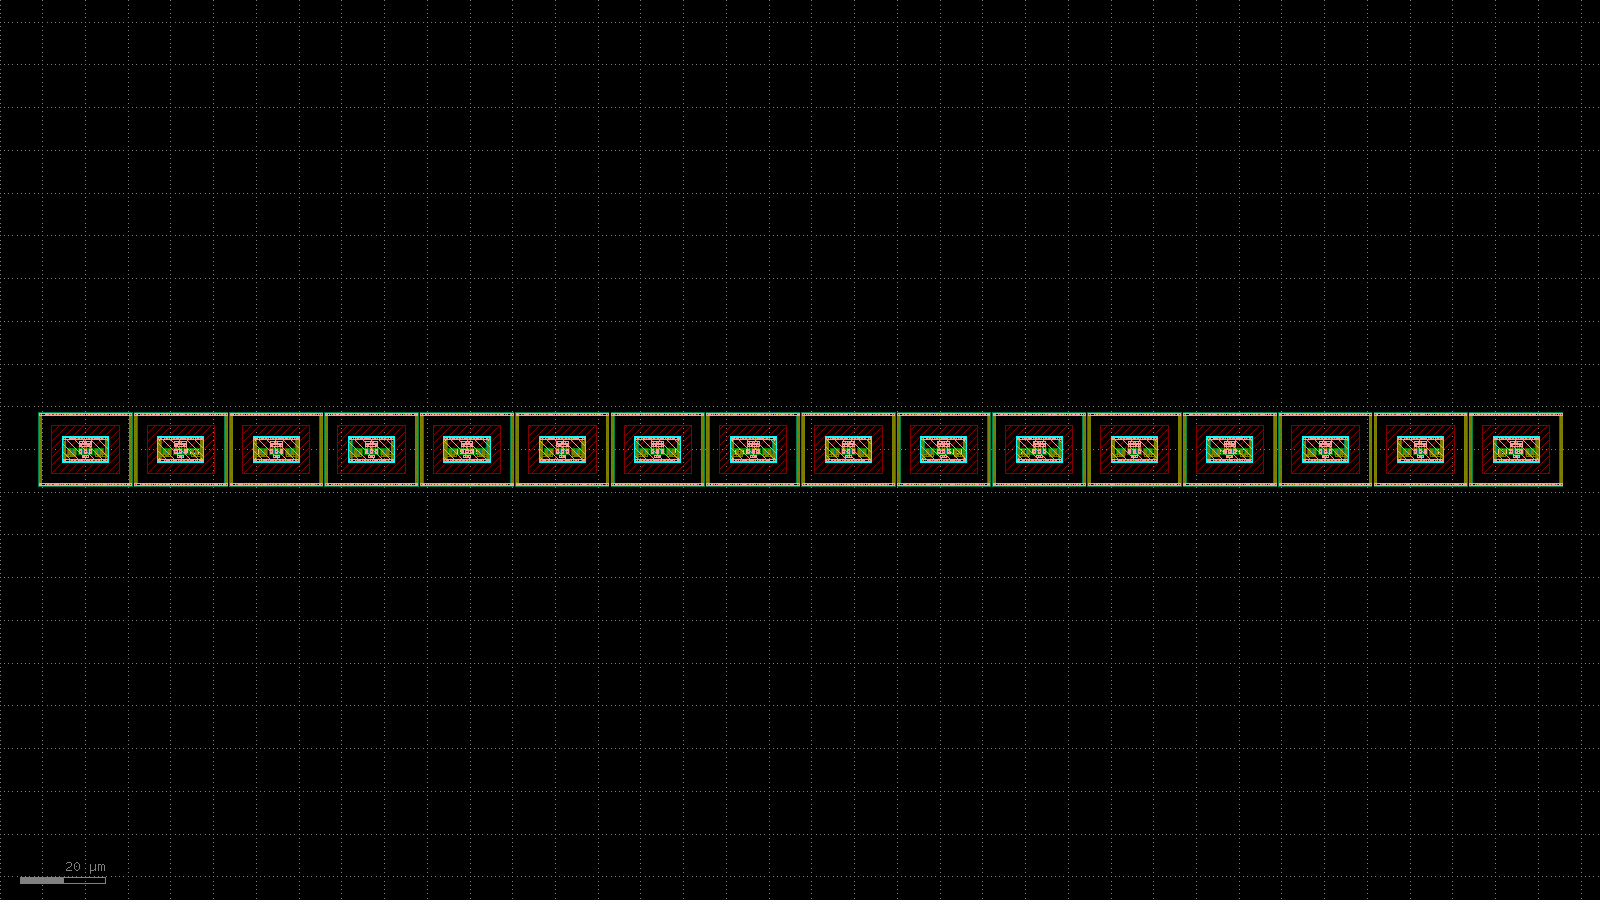

Cell: mtp_row_8bit | 356.6 µm × 17.1 µm | 25 cells


In [7]:
show_gds(os.path.join(NB_DIR, 'mtp_row_8bit.gds'))


## 4. Summary

- MTP stores per-element calibration that survives power cycles and LEO radiation.
- Sense margin ΔI ≈ tens of µA → easily captured by a small cross-coupled latch.
- Tiling: bit cell → 8-bit row → byte-wide array → full NVM block.
- **You have now seen every block in the Ka-band RX chain!**
  Proceed to **00_Overview** for the full system picture.